# Adult Income Dataset: End-to-End Classification Pipeline with EDA, Feature Engineering & Machine Learning using KNN with GridSearchCV for Hyperparameter Tuning

# Adult Income Dataset Analysis

## Project Goal

This project explores the Adult Income dataset through:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Classification Modeling
- Model Evaluation

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_wine
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder, RobustScaler, MinMaxScaler, OrdinalEncoder, LabelEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression,SGDRegressor, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

# EDA and Visualization

In [40]:
df = pd.read_csv('adult_income.csv')

In [41]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [42]:
print("=== Dataset Shape ===")
print(df.shape)

=== Dataset Shape ===
(48842, 15)


In [43]:
print("\n=== Feature & Sample Count ===")
print(f"Total potential features: {df.shape[1]}")
print(f"Total sample data: {df.shape[0]}")


=== Feature & Sample Count ===
Total potential features: 15
Total sample data: 48842


In [44]:
print("\n=== First 10 Rows ===")
print(df.head(10))


=== First 10 Rows ===
   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   
5   37            Private  284582     Masters             14   
6   49            Private  160187         9th              5   
7   52   Self-emp-not-inc  209642     HS-grad              9   
8   31            Private   45781     Masters             14   
9   42            Private  159449   Bachelors             13   

           marital-status          occupation    relationship    race  \
0           Never-married        Adm-clerical   Not-in-family   White   
1      Married-civ-spouse     Exec-managerial         Husband   White   
2                Divorced   Handlers-cleaners   Not-i

In [45]:
print("\n=== Random 10 Rows ===")
print(df.sample(10))


=== Random 10 Rows ===
       age     workclass  fnlwgt      education  education-num  \
26210   39       Private  356838        HS-grad              9   
18635   48       Private   30289           10th              6   
46733   31       Private  382583        HS-grad              9   
36905   51       Private   57637        HS-grad              9   
4694    46       Private  155659   Some-college             10   
45490   43       Private   68748        HS-grad              9   
6879    41   Federal-gov  564135        Masters             14   
35636   31     State-gov  268832        HS-grad              9   
38344   64             ?  155142        HS-grad              9   
14539   30     Local-gov  182926   Some-college             10   

            marital-status          occupation     relationship    race  \
26210        Never-married     Farming-fishing        Own-child   White   
18635   Married-civ-spouse        Craft-repair          Husband   White   
46733        Never-marri

In [46]:
print("\n=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [47]:
print("\n=== Descriptive Statistics ===")
print(df.describe())


=== Descriptive Statistics ===
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    48842.000000  
mean        40.422382  
std         12.391444  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [48]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [49]:
print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())


=== Duplicate Rows ===
29


In [50]:
df.drop_duplicates(inplace=True)
print("Duplicates removed")

Duplicates removed


In [51]:
print(df['workclass'].unique())
print(df['education'].unique())
print(df['occupation'].unique())
print(df['relationship'].unique())
print(df['race'].unique())
print(df['sex'].unique())
print(df['native-country'].unique())
print(df['marital-status'].unique())

[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']
[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
[' Male' ' Female']
[' United-States' ' Cuba' ' Jamaica' ' India' ' ?' ' Mexico' ' South'
 ' Puerto-Rico' ' Honduras' ' England' ' Canada' ' Germany' ' Iran'
 ' Philippines' ' Italy' ' Poland' ' Columbia' ' Cambodia' ' Thailand'
 ' Ecuador' ' Laos' ' Taiwan' ' Haiti' ' Port

In [52]:
# Text Cleaning of Categorical Variables (Removing Noise and Formatting Issues)

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].str.replace(' ', '')
    df[col] = df[col].str.replace('.', '').str.strip()

print("Text Cleaning of Categorical Variables (Removing Noise and Formatting Issues)")

Text Cleaning of Categorical Variables (Removing Noise and Formatting Issues)


In [53]:
# Handling Missing Values (Replacing '?' with NaN)

df.replace('?', np.nan, inplace=True)

print("Handling Missing Values (Replacing '?' with NaN)")

Handling Missing Values (Replacing '?' with NaN)


In [54]:
print(df['workclass'].unique())
print(df['education'].unique())
print(df['occupation'].unique())
print(df['relationship'].unique())
print(df['race'].unique())
print(df['sex'].unique())
print(df['native-country'].unique())
print(df['marital-status'].unique())

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
['Male' 'Female']
['United-States' 'Cuba' 'Jamaica' 'India' nan 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan'

## Insights

- The Adult Income dataset contains demographic and employment-related information that can be used to analyze income patterns.
- Initial exploration revealed a mix of numerical and categorical features requiring different preprocessing strategies.
- Duplicate records were detected and removed to improve dataset quality.
- Missing values represented by placeholder symbols were identified and prepared for further treatment.
- Categorical features were standardized through text cleaning to ensure consistency.
- The dataset is well-suited for machine learning tasks after proper preprocessing and feature engineering.

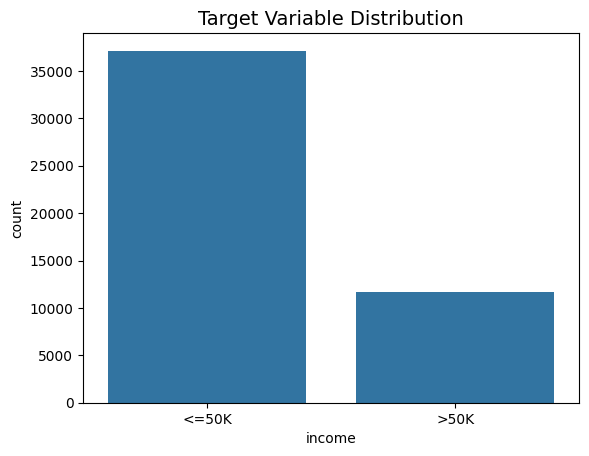

In [55]:
sns.countplot(data=df, x='income')
plt.title("Target Variable Distribution", fontsize=14)
plt.show()

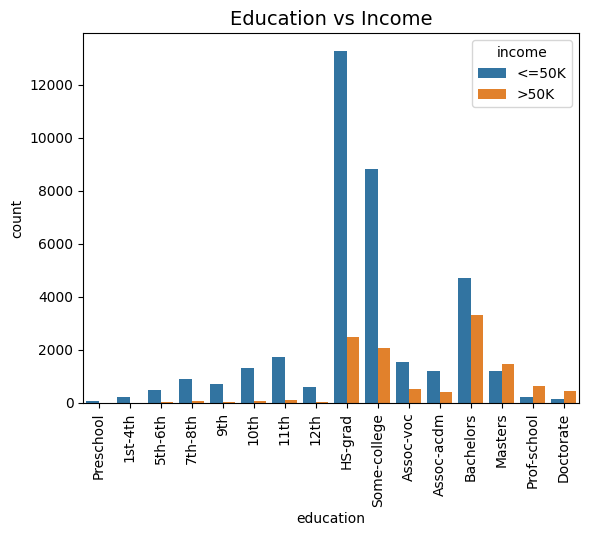

In [56]:
# Education Feature

education_order = ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th','HS-grad','Some-college','Assoc-voc','Assoc-acdm','Bachelors','Masters','Prof-school','Doctorate']

sns.countplot(data=df,x='education',hue='income',order=education_order)

plt.xticks(rotation=90)
plt.title("Education vs Income", fontsize=14)
plt.show()

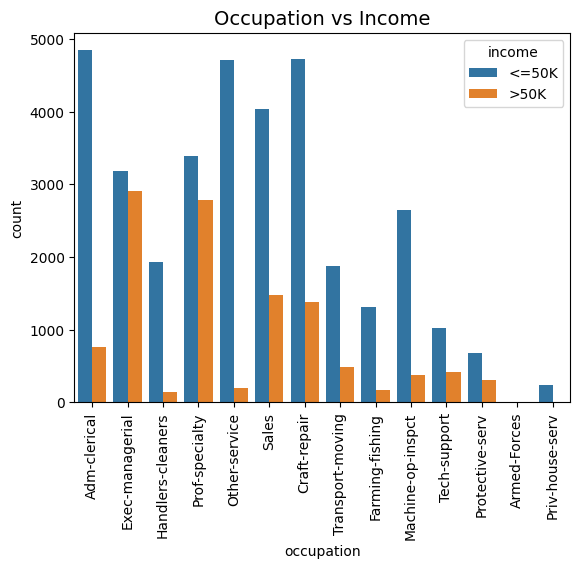

In [57]:
sns.countplot(
    data=df,
    x='occupation',
    hue='income'
)

plt.xticks(rotation=90)
plt.title("Occupation vs Income", fontsize=14)
plt.show()

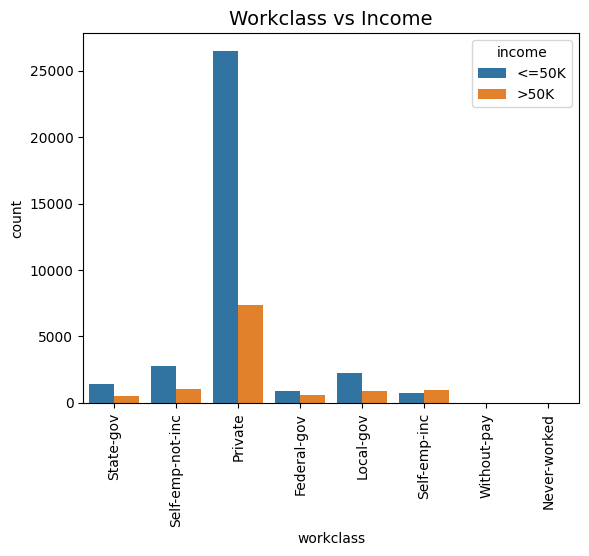

In [58]:
sns.countplot(
    data=df,
    x='workclass',
    hue='income'
)

plt.xticks(rotation=90)
plt.title("Workclass vs Income", fontsize=14)
plt.show()

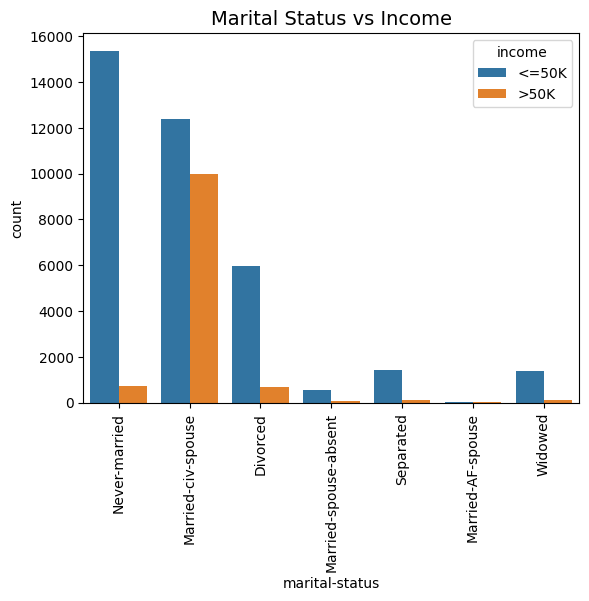

In [59]:
sns.countplot(
    data=df,
    x='marital-status',
    hue='income'
)

plt.xticks(rotation=90)

plt.title("Marital Status vs Income", fontsize=14)
plt.show()

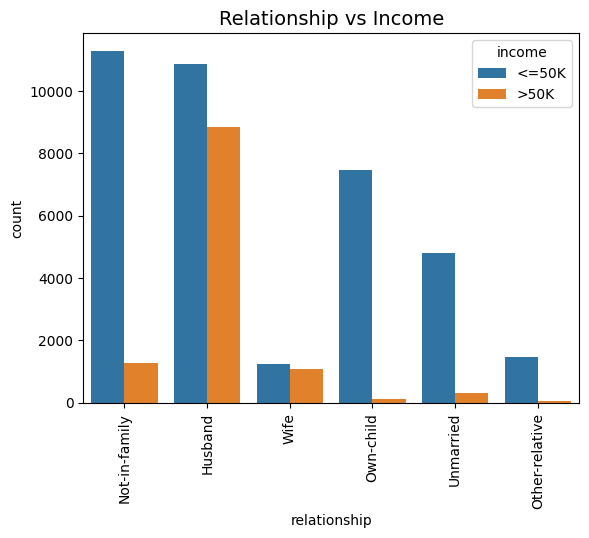

In [60]:
sns.countplot(
    data=df,
    x='relationship',
    hue='income'
)

plt.title("Relationship vs Income", fontsize=14)
plt.xticks(rotation=90)
plt.show()

In [61]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

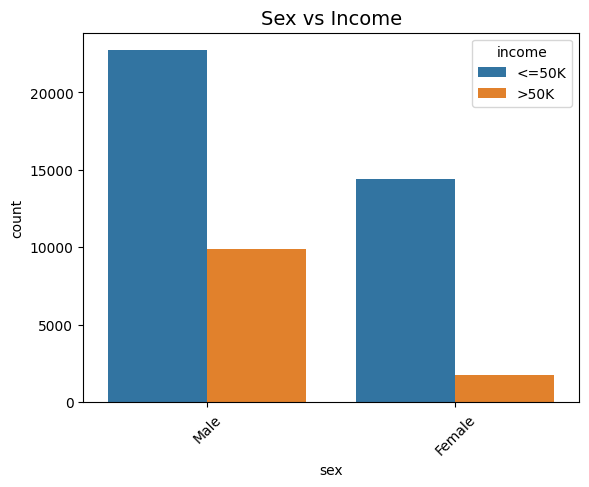

In [62]:
sns.countplot(
    data=df,
    x='sex',
    hue='income'
)

plt.title("Sex vs Income", fontsize=14)
plt.xticks(rotation=45)
plt.show()

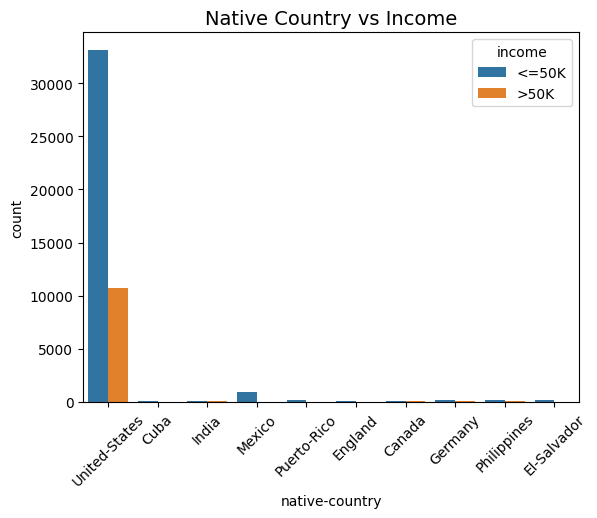

In [63]:
top = df['native-country'].value_counts().head(10).index

sns.countplot(
    data=df[df['native-country'].isin(top)],
    x='native-country',
    hue='income'
)

plt.title("Native Country vs Income", fontsize=14)
plt.xticks(rotation=45)
plt.show()

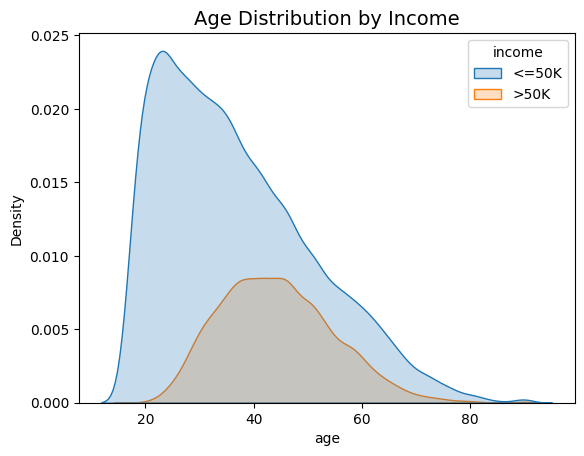

In [64]:
sns.kdeplot(
    data=df,
    x='age',
    hue='income',
    fill=True
)
plt.title("Age Distribution by Income", fontsize=14)

plt.show()

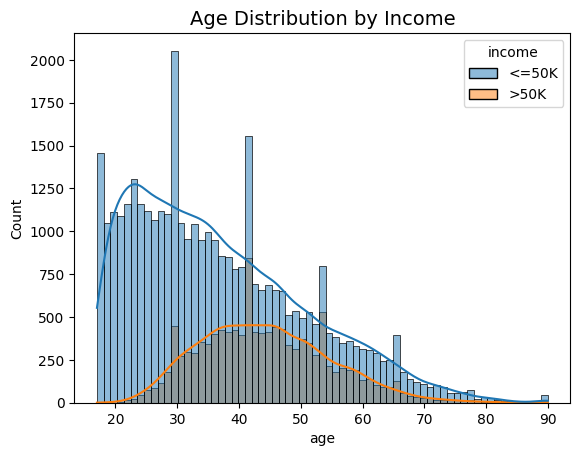

In [65]:
sns.histplot(
    data=df,
    x='age',
    hue='income',
    kde=True
)

plt.title("Age Distribution by Income", fontsize=14)

plt.show()

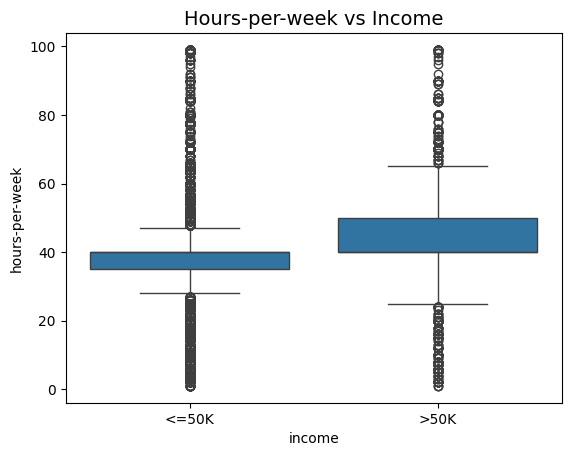

In [66]:
sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title("Hours-per-week vs Income", fontsize=14)

plt.show()

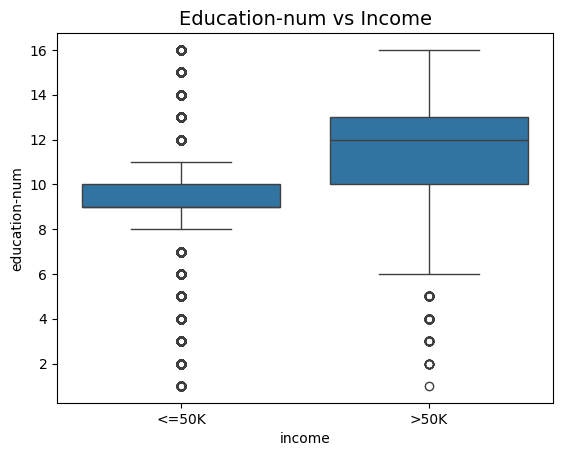

In [67]:
sns.boxplot(
    data=df,
    x='income',
    y='education-num'
)

plt.title("Education-num vs Income", fontsize=14)

plt.show()

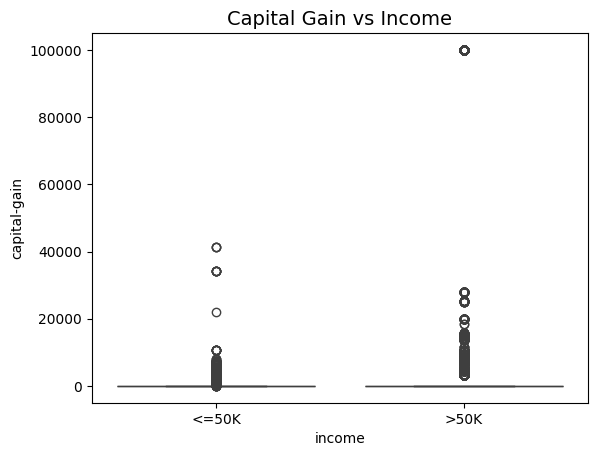

In [68]:
sns.boxplot(
    data=df,
    x='income',
    y='capital-gain'
)

plt.title("Capital Gain vs Income", fontsize=14)

plt.show()

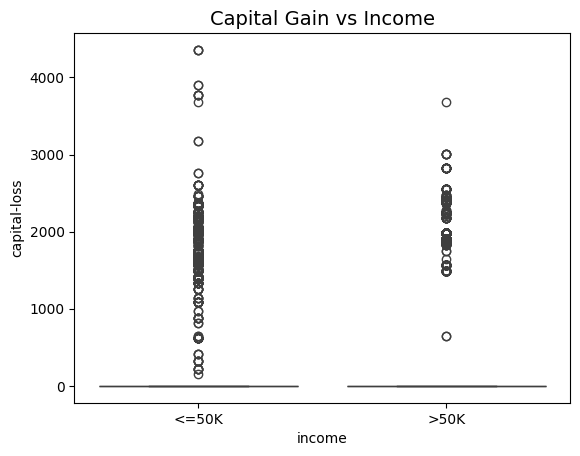

In [69]:
sns.boxplot(
    data=df,
    x='income',
    y='capital-loss'
)

plt.title("Capital Gain vs Income", fontsize=14)

plt.show()

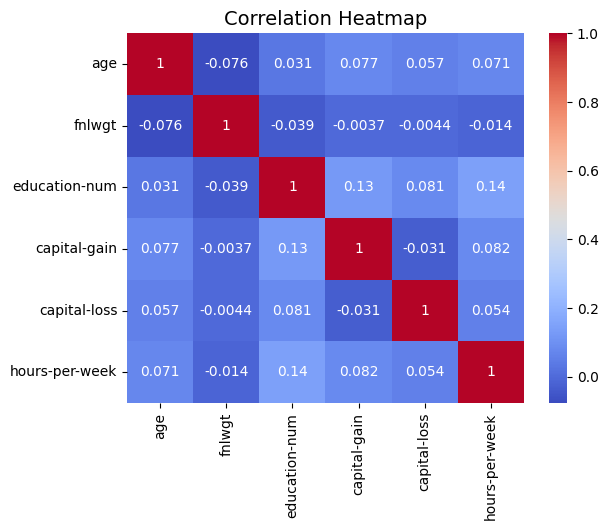

In [70]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap", fontsize=14)

plt.show()

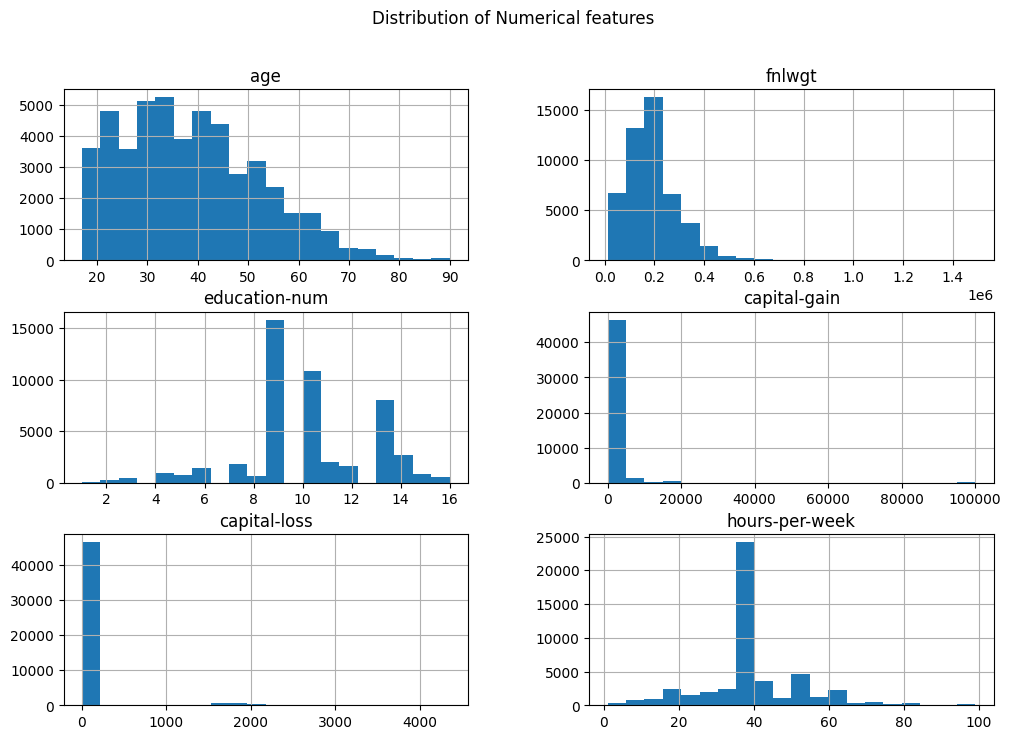

In [71]:
df.hist(figsize = (12,8), bins = 20)

plt.suptitle("Distribution of Numerical features")
plt.show()

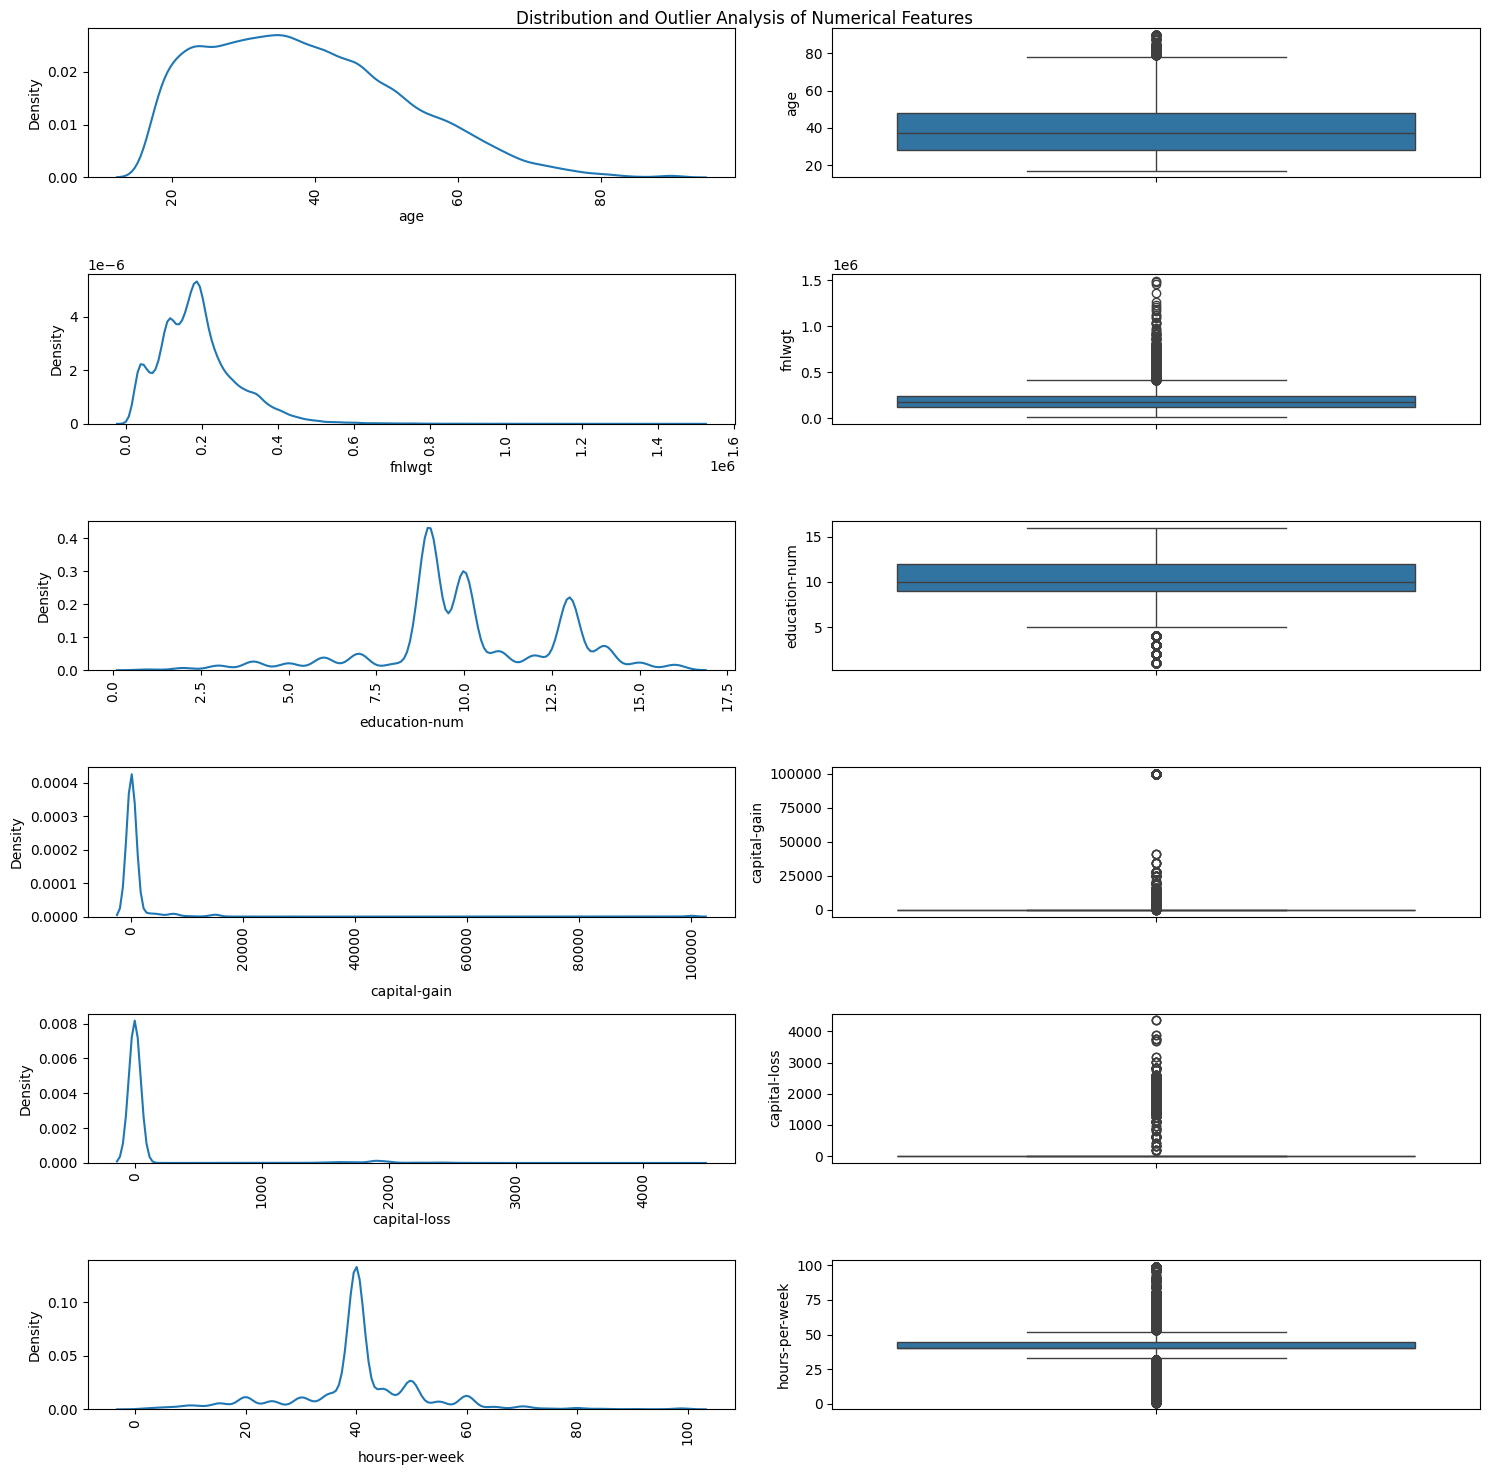

In [72]:
fig, axes = plt.subplots(6, 2, figsize=(15, 15))

sns.kdeplot(df['age'], ax=axes[0,0])
sns.boxplot(df['age'], ax=axes[0,1])

sns.kdeplot(df['fnlwgt'], ax=axes[1,0])
sns.boxplot(df['fnlwgt'], ax=axes[1,1])

sns.kdeplot(df['education-num'], ax=axes[2,0])
sns.boxplot(df['education-num'], ax=axes[2,1])

sns.kdeplot(df['capital-gain'], ax=axes[3,0])
sns.boxplot(df['capital-gain'], ax=axes[3,1])

sns.kdeplot(df['capital-loss'], ax=axes[4,0])
sns.boxplot(df['capital-loss'], ax=axes[4,1])

sns.kdeplot(df['hours-per-week'], ax=axes[5,0])
sns.boxplot(df['hours-per-week'], ax=axes[5,1])

axes[0,0].tick_params(axis='x', rotation=90)
axes[0,1].tick_params(axis='x', rotation=90)
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,1].tick_params(axis='x', rotation=90)
axes[2,0].tick_params(axis='x', rotation=90)
axes[2,1].tick_params(axis='x', rotation=90)
axes[3,0].tick_params(axis='x', rotation=90)
axes[3,1].tick_params(axis='x', rotation=90)
axes[4,0].tick_params(axis='x', rotation=90)
axes[4,1].tick_params(axis='x', rotation=90)
axes[5,0].tick_params(axis='x', rotation=90)
axes[5,1].tick_params(axis='x', rotation=90)

plt.suptitle("Distribution and Outlier Analysis of Numerical Features")
plt.tight_layout()
plt.show()

# Feature Engineering & Preprocessing Pipeline Design (Classification)

In [73]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [74]:
# df=pd.read_csv('adult_income.csv')

# df.duplicated().sum()

# df.drop_duplicates(inplace=True)

# categorical_columns = df.select_dtypes(include = ["object"]).columns

# for col in categorical_columns:
#   df[col] = df[col].str.replace(' ', '')
#   df[col] = df[col].str.replace('.', '').str.strip()

# df.replace('?', np.nan, inplace=True)

X = df.drop(columns=["income", "education"])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer_p1 = Pipeline(steps = [
    ('imputer1', SimpleImputer(missing_values=np.nan , strategy='most_frequent')),
    ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ])

imputer_p2 = Pipeline(steps = [
    ('imputer2', SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)),
    ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ])

num_transformer = Pipeline(steps = [('scaler',StandardScaler())])

cat_transformer = Pipeline(steps = [
    ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))])


preprocessor = ColumnTransformer(transformers = [
    ('imputer_1',imputer_p1, ['workclass', 'native-country']),
    ('imputer_2',imputer_p2, ['occupation']),
    ("numerical",num_transformer, ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']),
    ("categorical",cat_transformer,['marital-status',
       'relationship', 'race', 'sex']),
    ])

# Label Encoding for target column

le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

Predicting income using Logistic Regression

In [75]:
# ---- LogisticRegression ----

lr_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)

lr_model.fit(X_train,y_train)

y_pred = lr_model.predict(X_test)


print("---Logistic Regression---")
print()

lr_accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy Score : {lr_accuracy}')
lr_precision = precision_score(y_test,y_pred)
print(f'Precision Score : {lr_precision}')
lr_recall = recall_score(y_test,y_pred)
print(f'Recall Score : {lr_recall}')


---Logistic Regression---

Accuracy Score : 0.8065143910683191
Precision Score : 0.5645161290322581
Recall Score : 0.8386820710312366


# Predicting income using KNN with GridSearchCV for Hyperparameter Tuning

In [76]:
# ---- knn pipeline ----

knn_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('knn',KNeighborsClassifier(n_jobs=-1))
    ]
)
# knn_model.fit(X_train,y_train)

# ---------------------GridSearchCV---------------------

grid = {
    "knn__n_neighbors" : range(221,242, 2),
    "knn__weights" :['uniform','distance'],
    "knn__p" : [1,2]
}


grid_search = GridSearchCV(
    estimator = knn_model,
    param_grid = grid,
    cv = 5,
    n_jobs=-1,
)

grid_search.fit(X_train,y_train)

model = grid_search.best_estimator_

y_pred= model.predict(X_test)

print("---KNN Classifier with GridSearchCV---")
print()
knn_accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy Score : {knn_accuracy}')
knn_precision = precision_score(y_test,y_pred)
print(f'Precision Score : {knn_precision}')
knn_recall = recall_score(y_test,y_pred)
print(f'Recall Score : {knn_recall}')

---KNN Classifier with GridSearchCV---

Accuracy Score : 0.848612106934344
Precision Score : 0.7268885367142103
Recall Score : 0.5887890457851946


In [77]:
classification_compare = pd.DataFrame({
    'Model':     ['Logistic Regression (Default)', 'KNN (Tuned)'],
    'Accuracy':  [round(lr_accuracy,4),  round(knn_accuracy,4)],
    'Precision': [round(lr_precision,4), round(knn_precision,4)],
    'Recall':    [round(lr_recall,4),  round(knn_recall,4)]
})

print(classification_compare.to_string(index=False))

                        Model  Accuracy  Precision  Recall
Logistic Regression (Default)    0.8065     0.5645  0.8387
                  KNN (Tuned)    0.8486     0.7269  0.5888


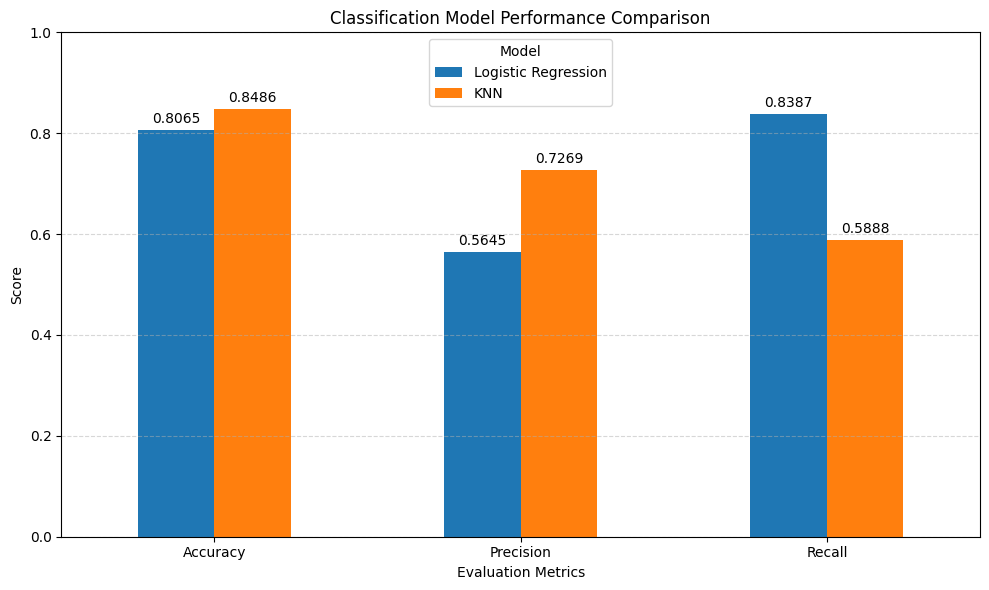

In [78]:
# Metrics to compare
metrics = ['Accuracy', 'Precision', 'Recall']

# Logistic Regression scores
lr_scores = [
    lr_accuracy,
    lr_precision,
    lr_recall
]

# KNN scores
knn_scores = [
    knn_accuracy,
    knn_precision,
    knn_recall
]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Logistic Regression': lr_scores,
    'KNN': knn_scores
})

# Plot
ax = comparison_df.set_index('Metric').plot(
    kind='bar',
    figsize=(10,6),
    rot=0
)


plt.title('Classification Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Model')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

# Conclusion

## Key Findings

• Education level strongly influences income.

• Capital Gain is one of the strongest predictors.

• Married individuals are more likely to belong to the >50K class.

• Logistic Regression and KNN achieved competitive performance after preprocessing.


# Logistic Regression Cross Validation

In [79]:
# ---------------- Cross Validation (Logistic Regression) ----------------

lr_cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("----- Logistic Regression Cross Validation -----")
print()

print("Cross Validation Scores:")
print(lr_cv_scores)

print()

print(f"Mean Accuracy : {lr_cv_scores.mean():.4f}")
print(f"Standard Deviation : {lr_cv_scores.std():.4f}")

----- Logistic Regression Cross Validation -----

Cross Validation Scores:
[0.8069241  0.8057974  0.81604015 0.81366523 0.80321655]

Mean Accuracy : 0.8091
Standard Deviation : 0.0049


# KNN (Best Model) Cross Validation

In [80]:
# ---------------- Cross Validation (Best KNN Model) ----------------

model = grid_search.best_estimator_

knn_cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("----- KNN Cross Validation -----")
print()

print("Cross Validation Scores:")
print(knn_cv_scores)

print()

print(f"Mean Accuracy : {knn_cv_scores.mean():.4f}")
print(f"Standard Deviation : {knn_cv_scores.std():.4f}")

----- KNN Cross Validation -----

Cross Validation Scores:
[0.84390044 0.84082761 0.84758783 0.84439664 0.84890391]

Mean Accuracy : 0.8451
Standard Deviation : 0.0029


# Cross Validation

To evaluate the model's generalization performance, 5-fold Cross Validation was performed.

Cross Validation helps assess how well the model is expected to perform on unseen data by training and validating it across multiple subsets of the dataset.

A low standard deviation indicates consistent performance across different folds, while the mean accuracy provides a more reliable estimate of the model's overall performance.